# Day 2 — Heterogeneity, the honest way first: subgroup ATEs

Day 1 established that both emails work **on average** (+7.7pp / +4.5pp visit lift). But an average is a summary of people, and people differ. Before any machine learning, we ask the heterogeneity question the way analysts did for decades: split by one **pre-treatment** covariate at a time and estimate the ATE inside each slice.

Why this is valid: randomization holds inside any pre-treatment slice — "rural customers" contains treated and control rural customers assigned by the same coin — so each subgroup is a smaller RCT and difference-in-means is unbiased within it.

Two disciplines applied here:

1. **Pre-registration.** We pick the subgrouping variables *before looking at results* (recency, history segment, channel, newbie), mirroring how a real experiment plan avoids cherry-picking slices after the fact.
2. **Multiple-comparisons honesty.** ~15 subgroup tests at α=0.05 will produce ~1 false positive by luck alone. We treat this section as *hypothesis-generating*, not confirmatory, and we do not chase individual p-values.

**Arm choice for the rest of the project: Womens E-Mail vs control.** Every customer in the dataset can receive a women's-merchandise email meaningfully (all purchased something; ~55% previously bought womens merchandise, but the email is not gender-targeted at the recipient). Its moderate average effect (+4.5pp) also leaves more room for *interesting* heterogeneity than the men's email, whose huge (+7.7pp) effect is strong almost everywhere — targeting matters most when the average effect is modest but uneven.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data import load_data, CONTROL
FIG_DIR = ROOT / "reports" / "figures"
ARM_COLORS = {"No E-Mail": "#6A6A6A", "Mens E-Mail": "#0072B2", "Womens E-Mail": "#CC7A00"}
pd.set_option("display.max_columns", 30)

df = load_data()

In [2]:
from src.validation import subgroup_ates

df["recency_band"] = pd.cut(df["recency"], [0, 4, 8, 12],
                            labels=["1-4 mo", "5-8 mo", "9-12 mo"])

SUBGROUP_VARS = ["recency_band", "history_segment", "channel", "newbie", "zip_code"]
tables = {v: subgroup_ates(df, "visit", "Womens E-Mail", CONTROL, v) for v in SUBGROUP_VARS}
sub_all = pd.concat(tables.values())
sub_all.round(4)

,n,mean_treat,mean_control,ate,ci_low,ci_high,p_value
subgroup,,,,,,,
recency_band=1-4 mo,27470,0.1744,0.1329,0.0415,0.0311,0.0520,0.0000
recency_band=5-8 mo,16688,0.1463,0.0993,0.0470,0.0349,0.0591,0.0000
recency_band=9-12 mo,19842,0.1239,0.0746,0.0494,0.0392,0.0595,0.0000
history_segment=1) $0 - $100,22970,0.1316,0.0849,0.0468,0.0369,0.0566,0.0000
history_segment=2) $100 - $200,14254,0.1335,0.0910,0.0425,0.0299,0.0551,0.0000
history_segment=3) $200 - $350,12289,0.1625,0.1264,0.0361,0.0209,0.0513,0.0000
history_segment=4) $350 - $500,6409,0.1906,0.1502,0.0404,0.0180,0.0628,0.0004
history_segment=5) $500 - $750,4911,0.1757,0.1096,0.0661,0.0424,0.0898,0.0000
"history_segment=6) $750 - $1,000",1859,0.2091,0.1543,0.0548,0.0114,0.0981,0.0132


**Reading the table:** every row is its own mini-experiment. `ate` is the visit-rate lift for that slice; the CI reflects the slice's (smaller) sample size — subgroup CIs are necessarily wider than the overall ATE's.

<>:13: SyntaxWarning: invalid escape sequence '\$'
<>:13: SyntaxWarning: invalid escape sequence '\$'
C:\Users\cuiha\AppData\Local\Temp\ipykernel_33852\3047736665.py:13: SyntaxWarning: invalid escape sequence '\$'
  ax.set_yticks(range(len(plot)), plot["subgroup"].str.replace("$", "\$", regex=False))


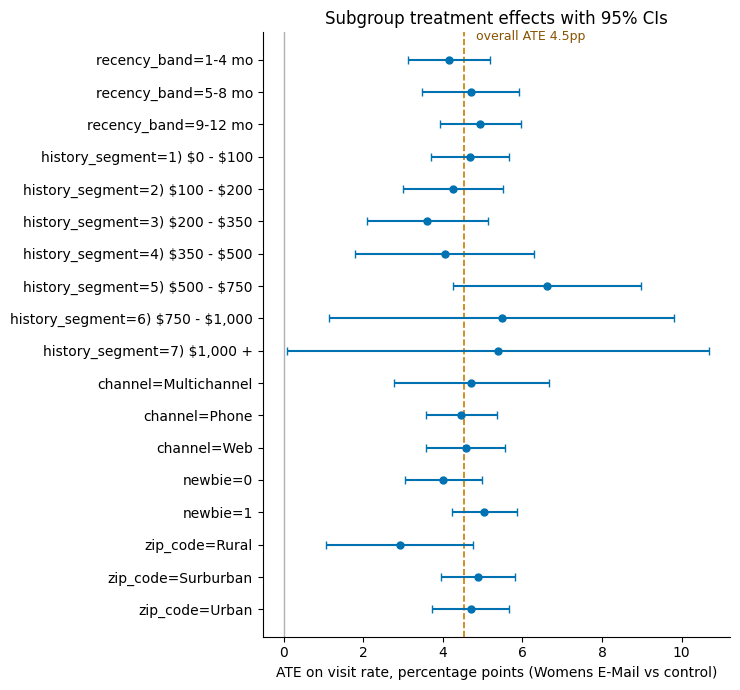

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 7))
plot = sub_all.reset_index().iloc[::-1]
ax.axvline(0, color="#B0B0B0", lw=1)
overall = df.pipe(lambda d: d[d.segment == "Womens E-Mail"]["visit"].mean()
                  - d[d.segment == CONTROL]["visit"].mean())
ax.axvline(overall * 100, color="#CC7A00", lw=1.2, ls="--")
ax.annotate(f"overall ATE {overall*100:.1f}pp", (overall * 100, len(plot) - 0.4),
            color="#8a5200", fontsize=9, ha="left", xytext=(overall * 100 + 0.3, len(plot) - 0.4))
for i, (_, r) in enumerate(plot.iterrows()):
    ax.errorbar(r["ate"] * 100, i,
                xerr=[[(r["ate"] - r["ci_low"]) * 100], [(r["ci_high"] - r["ate"]) * 100]],
                fmt="o", color="#0072B2", capsize=3, markersize=5)
ax.set_yticks(range(len(plot)), plot["subgroup"].str.replace("$", "\$", regex=False))
ax.set_xlabel("ATE on visit rate, percentage points (Womens E-Mail vs control)")
ax.set_title("Subgroup treatment effects with 95% CIs")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "day2_subgroup_ates.png", dpi=200)
plt.show()

## What the subgroups say

Most CIs overlap the overall ATE — one-variable-at-a-time slicing finds *suggestive* patterns, not dramatic ones. Two slices stand out against the dashed line: **higher prior-spend segments trend above average** (\$500–750: ~6.6pp) while **rural customers trend below** (~2.9pp); recency and channel show little gradient. With ~18 intervals on one plot, a couple of excursions are expected by chance — noted, not over-claimed.

Two structural limits of this approach motivate the next notebook:

1. **One dimension at a time.** The email might work best for *recent + high-history + web* customers — a three-way pattern invisible to marginal slices, and slicing three ways at once shreds the sample.
2. **No individual scores.** Policy needs a *ranking of customers*, not a table of group averages.

Both are exactly what CATE models (notebook 03) provide: τ(x) = E[Y(1) − Y(0) | X = x], estimated with ML that handles all covariates jointly, per customer.